In [1]:
pip install alpaca-py


   -------------------- ------------------- 1/2 [alpaca-py]
   ---------------------------------------- 2/2 [alpaca-py]

Note: you may need to restart the kernel to use updated packages.


In [1]:
from alpaca.trading.client import TradingClient

API_KEY = "PK5Z5VGT5SKKWOQXSRZ4ORRDNO"
SECRET_KEY = "CTN8b4tSqYzUj3xb8G4Kd5L4TXN4b9jdGAoNxkxhMAjG"

client = TradingClient(API_KEY, SECRET_KEY, paper=True)

account = client.get_account()
print(account)

id=UUID('c74df5a0-1b68-4c2c-a6af-dcf26673433d') account_number='PA3X8KRAB0TK' status=<AccountStatus.ACTIVE: 'ACTIVE'> crypto_status=<AccountStatus.ACTIVE: 'ACTIVE'> currency='USD' buying_power='400000' regt_buying_power='200000' daytrading_buying_power='400000' non_marginable_buying_power='100000' cash='100000' accrued_fees='0' pending_transfer_out=None pending_transfer_in=None portfolio_value='100000' pattern_day_trader=False trading_blocked=False transfers_blocked=False account_blocked=False created_at=datetime.datetime(2026, 6, 10, 16, 10, 57, 578916, tzinfo=TzInfo(0)) trade_suspended_by_user=False multiplier='4' shorting_enabled=True equity='100000' last_equity='100000' long_market_value='0' short_market_value='0' initial_margin='0' maintenance_margin='0' last_maintenance_margin='0' sma='100000' daytrade_count=0 options_buying_power='100000' options_approved_level=3 options_trading_level=3


[*********************100%***********************]  1 of 1 completed


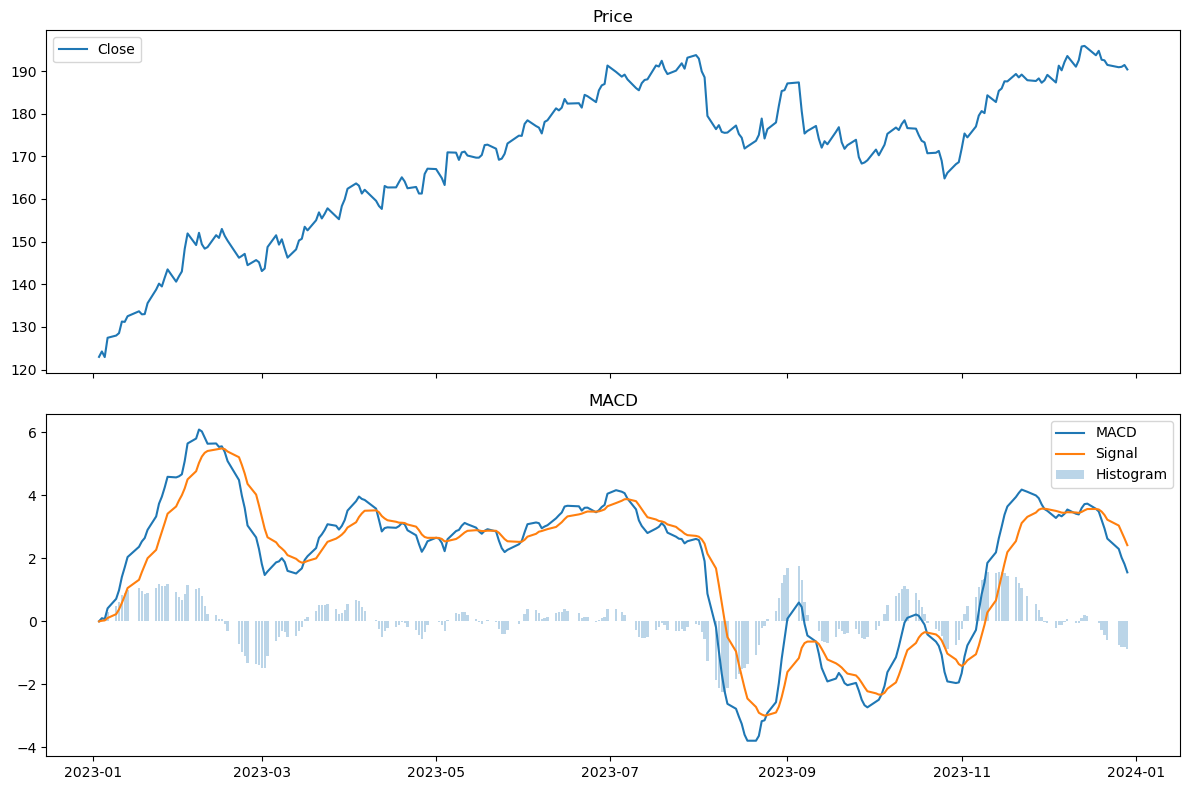

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

def calculate_macd(df, fast=12, slow=26, signal=9):
    # calculate fast and slow EMAs
    df['ema_fast'] = df['Close'].ewm(span=fast, adjust=False).mean()
    df['ema_slow'] = df['Close'].ewm(span=slow, adjust=False).mean()
    
    # calculate MACD line (fast minus slow)
    df['macd'] = df['ema_fast'] - df['ema_slow']
    
    # calculate signal line (EMA of MACD line)
    df['signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    
    # calculate histogram (MACD minus signal)
    df['hist'] = df['macd'] - df['signal']

    return df

def plot_macd(df):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # plot price on top
    ax1.plot(df.index, df['Close'], label='Close')
    ax1.set_title('Price')
    ax1.legend()

    # plot MACD line and signal line in middle
    ax2.plot(df.index, df['macd'], label='MACD')
    ax2.plot(df.index, df['signal'], label='Signal')

    # plot histogram on bottom
    ax2.bar(df.index, df['hist'], label='Histogram', alpha=0.3)
    ax2.set_title('MACD')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    pass

# download data
ticker = "AAPL"
df = yf.download(ticker, start="2023-01-01", end="2024-01-01")

# calculate and plot
df = calculate_macd(df)
plot_macd(df)

In [ ]:
from datetime import datetime, time as dtime
from zoneinfo import ZoneInfo

def is_market_open():
    now = datetime.now(ZoneInfo("America/New_York"))
    open_time = dtime(9, 30)
    close_time = dtime(16, 0)
    if now.weekday() < 5 and (open_time <= now.time() <= close_time):
        # check to see if there are market actions to take since the market is open
        return True
    return False


The market is closed
